# Lab 10 – NLP Evaluation with TextBlob & NLTK

Dataset: `amazon_review.csv` (colonnes `reviewText`, `Positive`)

In [1]:
# ── Installations & téléchargements NLTK ──────────────────────────────────
!pip install textblob wordcloud --quiet
from textblob import TextBlob
import nltk
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'averaged_perceptron_tagger',
            'averaged_perceptron_tagger_eng', 'wordnet', 'brown',
            'conll2000', 'movie_reviews']:
    nltk.download(pkg, quiet=True)
print('Setup done ✓')

Setup done ✓


In [2]:
import pandas as pd
df = pd.read_csv('amazon_review.csv')
print(df.shape)
df.head()

(200, 2)


,reviewText,Positive
0,Does not work as advertised. Waste of time and...,0
1,I love this app so much. It makes my life so m...,1
2,This is a silly game and can be frustrating bu...,1
3,Garbage app. Nothing works properly. Uninstall...,0
4,Super fun and addictive game. I play it all th...,1


## Question 1 – Sentiment Analysis & Bar Chart

Classer chaque avis en *positive*, *negative* ou *neutral* avec TextBlob, puis afficher la distribution.

sentiment
positive    118
negative     41
neutral      41
Name: count, dtype: int64


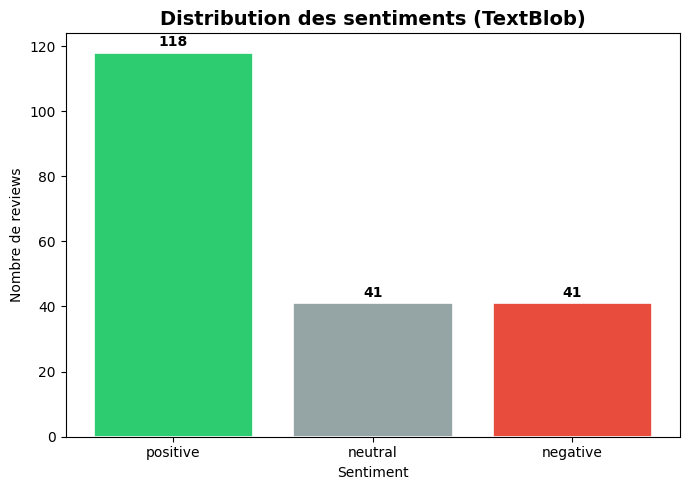

In [3]:
import matplotlib.pyplot as plt

# ── 1. Sentiment TextBlob ──────────────────────────────────────────────────
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.1:
        return 'positive'
    elif polarity < -0.1:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['reviewText'].apply(get_sentiment)
print(df['sentiment'].value_counts())

# ── 2. Bar chart ───────────────────────────────────────────────────────────
counts = df['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'])
colors = ['#2ecc71', '#95a5a6', '#e74c3c']

plt.figure(figsize=(7, 5))
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.title('Distribution des sentiments (TextBlob)', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Nombre de reviews')
plt.tight_layout()
plt.show()

## Question 2 – Prétraitement du texte

Minuscules → suppression ponctuation & chiffres → stopwords → lemmatisation avec POS tags.

In [4]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from nltk.corpus import wordnet

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    """Convertit un tag Penn Treebank en tag WordNet."""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN  # défaut

def preprocess(text):
    # Minuscules
    text = str(text).lower()
    # Suppression ponctuation & chiffres
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenisation
    tokens = word_tokenize(text)
    # Suppression stopwords + mots courts
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # POS tagging
    tagged = pos_tag(tokens)
    # Lemmatisation
    lemmas = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]
    return lemmas

df['tokens'] = df['reviewText'].apply(preprocess)
print('Exemple (ligne 0):')
print('Original :', df['reviewText'].iloc[0][:80])
print('Tokens   :', df['tokens'].iloc[0])

Exemple (ligne 0):
Original : Does not work as advertised. Waste of time and money.
Tokens   : ['work', 'advertise', 'waste', 'time', 'money']


## Question 3 – Top 15 mots les plus fréquents

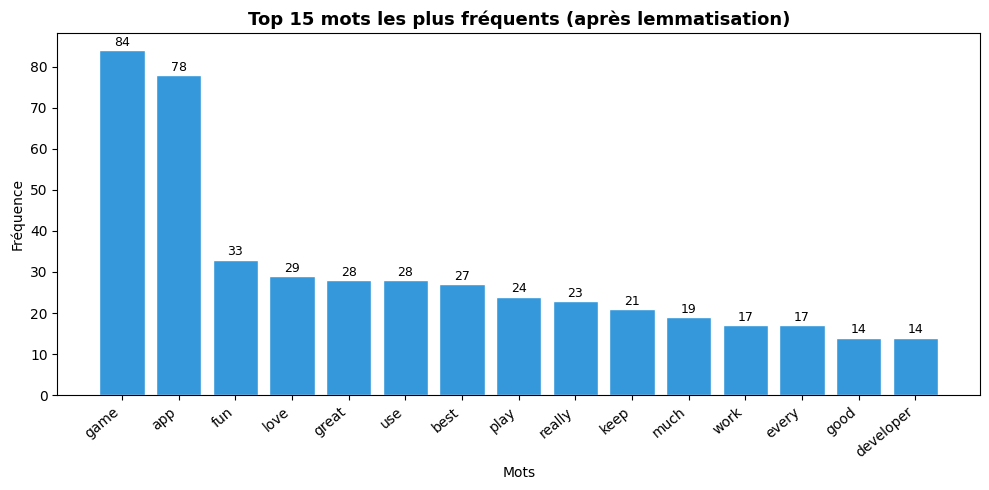

In [5]:
from collections import Counter

# Corpus complet : liste plate de tous les lemmes
all_tokens = [token for tokens in df['tokens'] for token in tokens]
freq = Counter(all_tokens)
top15 = freq.most_common(15)

words, counts = zip(*top15)

plt.figure(figsize=(10, 5))
bars = plt.bar(words, counts, color='#3498db', edgecolor='white')
for bar, val in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=9)
plt.title('Top 15 mots les plus fréquents (après lemmatisation)', fontsize=13, fontweight='bold')
plt.xlabel('Mots')
plt.ylabel('Fréquence')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

## Question 4 – Word Cloud

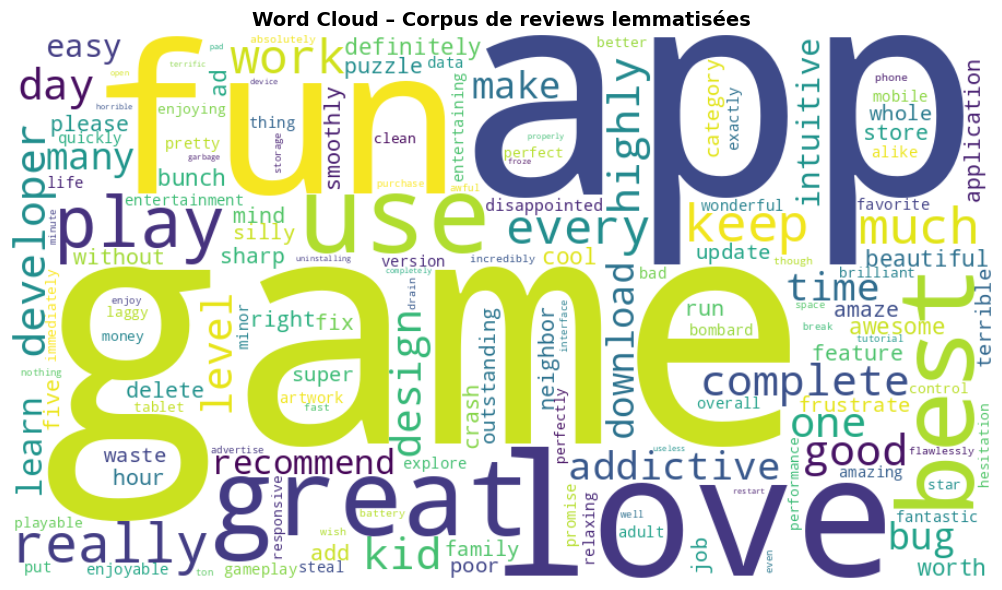

In [6]:
from wordcloud import WordCloud

text_for_cloud = ' '.join(all_tokens)

wc = WordCloud(
    width=900, height=500,
    background_color='white',
    colormap='viridis',
    max_words=150,
    collocations=False
).generate(text_for_cloud)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud – Corpus de reviews lemmatisées', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Question 5 – Fréquence des noms, verbes, adjectifs

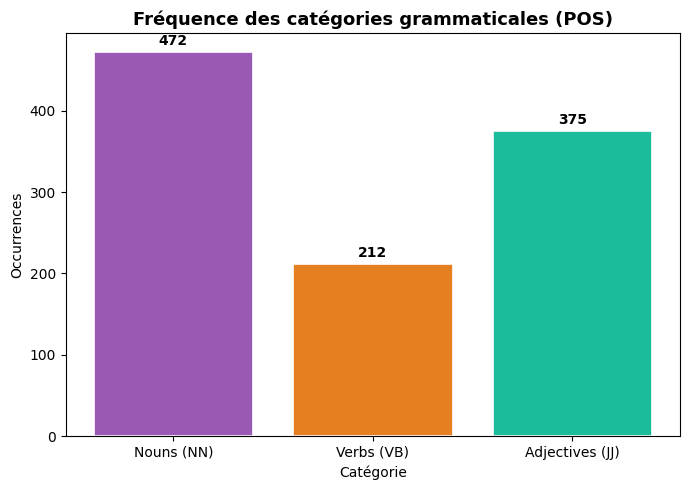

In [7]:
from nltk import pos_tag, word_tokenize

# POS tagging sur le corpus complet (tokenisation simple)
all_text = ' '.join(df['reviewText'].astype(str).str.lower())
all_text = re.sub(r'[^a-z\s]', '', all_text)
tokens_raw = word_tokenize(all_text)
tokens_raw = [t for t in tokens_raw if t not in stop_words and len(t) > 2]

tagged_all = pos_tag(tokens_raw)

noun_count = sum(1 for _, tag in tagged_all if tag.startswith('NN'))
verb_count = sum(1 for _, tag in tagged_all if tag.startswith('VB'))
adj_count  = sum(1 for _, tag in tagged_all if tag.startswith('JJ'))

categories = ['Nouns (NN)', 'Verbs (VB)', 'Adjectives (JJ)']
values     = [noun_count, verb_count, adj_count]
colors_pos = ['#9b59b6', '#e67e22', '#1abc9c']

plt.figure(figsize=(7, 5))
bars = plt.bar(categories, values, color=colors_pos, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.title('Fréquence des catégories grammaticales (POS)', fontsize=13, fontweight='bold')
plt.xlabel('Catégorie')
plt.ylabel('Occurrences')
plt.tight_layout()
plt.show()